# Week 36, Tuesday session: the bias-variance tradeoff and cross-validation in practice

**FYS-STK3155/4155, Tuesday September 1, 2026**

This is the companion notebook to Monday's lecture (`week36slides.pdf`) and
Tuesday's steering deck (`week36tuesday.pdf`). We work through **two cases
only**, deliberately:

1. **Case 1:** the bias-variance decomposition, Eq. (2.52) of the book, measured
   with the bootstrap — reproduced, then stress-tested;
2. **Case 2:** $k$-fold cross-validation for the Ridge penalty $\lambda$ (and for
   the polynomial degree), written by hand and validated against `scikit-learn` —
   and then the full recipe of the new Section 3.14 of the book: standard errors
   over the folds, the one-standard-error rule, the refit on all training data,
   one look at the test set, the Lasso side by side with Ridge, and why
   cross-validation rather than the bootstrap chooses $\lambda$.

All seeds are 2026, so your figures reproduce the lecture figures exactly.
Work in pairs or small groups; the plenary checkpoints are on the Tuesday
slides. The code you write here is directly reusable in this week's exercise
set (deadline Friday September 4) and in Project 1.

Reading: Chapter 2, Sections 2.9–2.12 (and 2.3–2.8 for the statistical toolbox), and Section 3.14 of Chapter 3.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm

# the color palette used in the weekly slides
BLUE, RED, YELLOW = "#004488", "#BB5566", "#DDAA33" 

## Case 1: the bias-variance decomposition, owned

The expectation over training sets in Eq. (2.52) is manufactured by the
**bootstrap**: we resample the training data with replacement, refit the model
on each resample, and average. The code below is exactly the code behind
Monday's figure (`week36_bias_variance.pdf`) and follows Section 2.10 of the
book.

### Step 1: reproduce the lecture figure

Recall the identity we derived on Monday (Eq. (2.52) of the book):

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \underbrace{\frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2}_{\mathrm{Bias}^2}
+ \underbrace{\frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2}_{\mathrm{Var}[\tilde{\boldsymbol{y}}]}
+ \sigma^2 .
$$

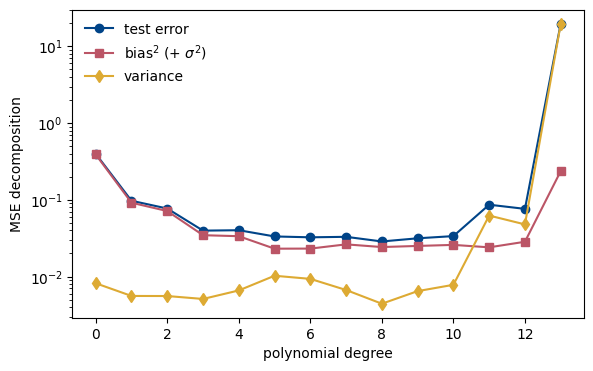

degree  0: error 0.3980  bias^2 0.3898  var 0.0082  sum 0.3980
degree  4: error 0.0401  bias^2 0.0336  var 0.0066  sum 0.0401
degree  8: error 0.0286  bias^2 0.0242  var 0.0044  sum 0.0286
degree 13: error 19.7520  bias^2 0.2367  var 19.5153  sum 19.7520


In [37]:
np.random.seed(2026)
n, n_bootstraps, maxdegree = 40, 100, 14

x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        x_, y_ = resample(x_train, y_train)
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()

for d in (0, 4, 8, maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}")

**Checkpoint questions** (discuss before moving on):

- At degree 0 the model predicts a constant, so its variance is tiny and the
  bias$^2 \approx 0.39$ is essentially the variance of $f$ itself. Why?
- The error and the sum bias$^2$ + variance agree to all printed digits. Where
  did $\sigma^2$ go? (Warm-up 2 has the answer.)
- The minimum is *broad*, degrees 5–9 — model selection rarely has a sharp
  answer.

### Step 2: vary the data size

To explore, we wrap the sweep in a function. Predictions from warm-up 3 in
hand, run $n = 100$ and $n = 400$.

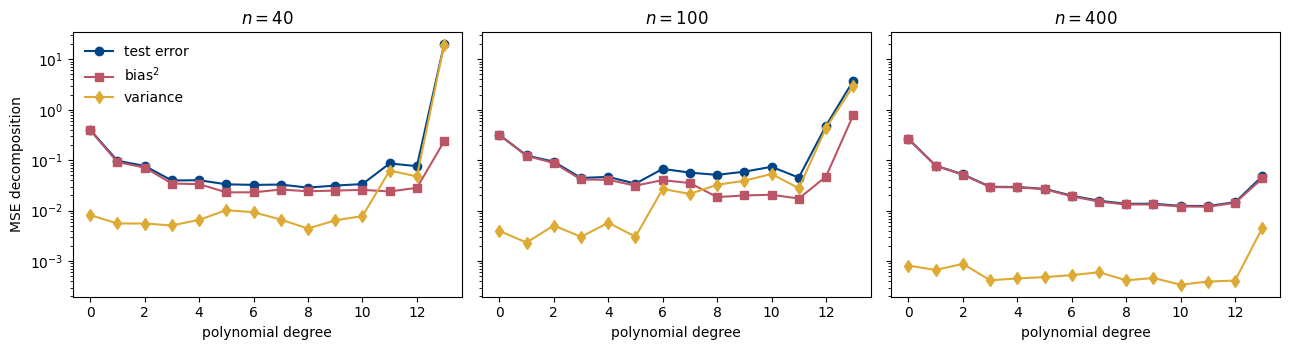

In [ ]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
maxdegree = 14
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_, maxdegree=maxdegree, n_bootstraps=100)
    ax.plot(range(maxdegree), err, "o-", color=BLUE, label="test error")
    ax.plot(range(maxdegree), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(maxdegree), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

Compare with your prediction: more data postpones the variance explosion
(the minimum moves right — a richer model becomes affordable), while the bias
curve, a property of the model family and not of $n$, barely moves.

### Step 3: vary the noise

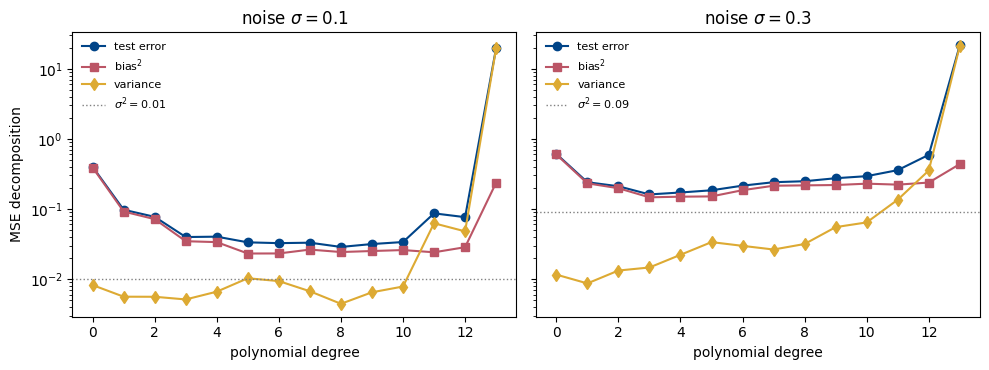

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, noise_ in zip(axes, (0.1, 0.3)):
    err, b2, var = bias_variance_sweep(n=40, noise=noise_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.axhline(noise_**2, color="gray", ls=":", lw=1,
               label=rf"$\sigma^2 = {noise_**2:.2f}$")
    ax.set_yscale("log")
    ax.set_title(rf"noise $\sigma = {noise_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
for ax in axes:
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

The floor rises with $\sigma^2$ (nine times higher for $\sigma=0.3$) and the
variance term scales up, while the bias$^2$ term is essentially unchanged —
noisier data favour simpler models, and the minimum shifts left.

### Step 4: the tradeoff as a dial — Ridge at fixed high degree

At degree 12 plain OLS is deep in the variance-explosion region. Now turn the
$\lambda$ dial and watch Eq. (2.52) rebalance.

In [40]:
degree_fixed = 12
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 40, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                       make_model=mk)
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance
     OLS      0.0762      0.0284      0.0478
  0.0001      0.0338      0.0272      0.0067
     0.1      0.0289      0.0228      0.0060
      10      0.1020      0.0979      0.0041


**Checkpoint:** as $\lambda$ grows the variance falls by orders of magnitude
while the bias creeps up — the tradeoff has become a dial you control. Which
$\lambda$ gives the smallest total error at degree 12, and does it beat plain
OLS at degree 6 from Step 1? (This is precisely the game cross-validation
automates in Case 2.)

---

## Case 2: cross-validation — choosing $\lambda$ without touching the test set

A single train/test split wastes data and depends on which points landed
where. **$k$-fold cross-validation** (Section 2.12): shuffle, split into $k$
folds, let each fold be the test set once, average the $k$ scores.

### Step 1: your own 5-fold loop

The data are $y = 3x^2 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0,1)$,
fitted by a degree-6 polynomial with Ridge. Note that the scaler is fitted
**inside** each fold, on the training folds only — Monday's "subtle leak"
warm-up explains why this matters.

In [53]:
rng = np.random.default_rng(2026)
n = 100
x = rng.standard_normal(n)
y = 3 * x**2 + rng.standard_normal(n)     # noise variance is 1

nlambdas = 100
lambdas = np.logspace(-3, 5, nlambdas)
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
poly = PolynomialFeatures(degree=6)

scores_KFold = np.zeros((nlambdas, k))
for i, lmb in enumerate(lambdas):
    for j, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        Xtrain = poly.fit_transform(xtrain[:, np.newaxis])
        Xtest = poly.transform(xtest[:, np.newaxis])
        scaler = StandardScaler().fit(Xtrain)   # fitted on the training folds only

        ridge = Ridge(alpha=lmb)
        ridge.fit(scaler.transform(Xtrain), ytrain)
        ypred = ridge.predict(scaler.transform(Xtest))
        scores_KFold[i, j] = np.mean((ypred - ytest)**2)
mse_KFold = np.mean(scores_KFold, axis=1)

### Step 2: validate against `cross_val_score`

The same computation in three lines, with the preprocessing wrapped in a
`Pipeline` so that it is refitted per fold. The two curves must coincide to
plotting accuracy — if they do not, the usual culprit is a scaler fitted on
the full data.

best lambda 1.177, cross-validated MSE 1.4569


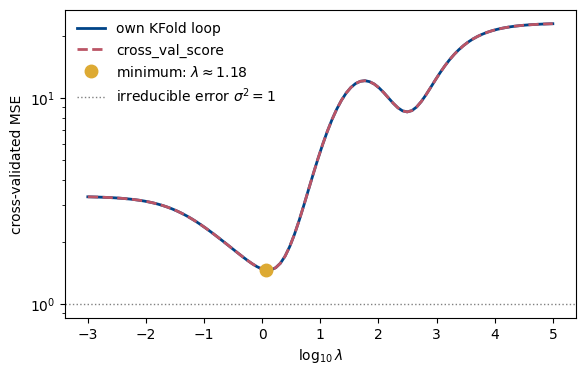

In [42]:
mse_sklearn = np.zeros(nlambdas)
for i, lmb in enumerate(lambdas):
    pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                         Ridge(alpha=lmb))
    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold,
                             scoring="neg_mean_squared_error")
    mse_sklearn[i] = np.mean(-scores)

best = np.argmin(mse_sklearn)
print(f"best lambda {lambdas[best]:.4g}, cross-validated MSE {mse_sklearn[best]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(np.log10(lambdas), mse_KFold, color=BLUE, lw=2, label="own KFold loop")
ax.plot(np.log10(lambdas), mse_sklearn, "--", color=RED, lw=2,
        label="cross_val_score")
ax.plot(np.log10(lambdas[best]), mse_sklearn[best], "o", color=YELLOW, ms=9,
        label=rf"minimum: $\lambda\approx{lambdas[best]:.3g}$")
ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()

**Reading the curve:** the minimum sits near $\lambda \approx 1$ with a CV-MSE
just above the known noise floor $\sigma^2 = 1$ — cross-validation has
recovered the irreducible error from 100 points. At $\lambda = 10^5$ every
coefficient is crushed, the model predicts the mean, and the error climbs to
the variance of $y$ itself.

### Step 3: how stable is the answer? Vary $k$

In [43]:
for k_ in (5, 10, 20):
    kf = KFold(n_splits=k_, shuffle=True, random_state=2026)
    mse_k = np.zeros(nlambdas)
    spread_k = np.zeros(nlambdas)
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                             Ridge(alpha=lmb))
        scores = -cross_val_score(pipe, x[:, np.newaxis], y, cv=kf,
                                  scoring="neg_mean_squared_error")
        mse_k[i] = scores.mean()
        spread_k[i] = scores.std()
    b = np.argmin(mse_k)
    print(f"k = {k_:2d}: lambda* = {lambdas[b]:8.4g}   CV-MSE = {mse_k[b]:.4f}"
          f"   spread over folds = {spread_k[b]:.4f}")

k =  5: lambda* =    1.177   CV-MSE = 1.4569   spread over folds = 0.4198
k = 10: lambda* =    2.057   CV-MSE = 1.4708   spread over folds = 0.6525
k = 20: lambda* =    2.057   CV-MSE = 1.4590   spread over folds = 1.0812


The location of the minimum is stable across $k$ (the CV curve is flat near
its minimum), while the spread over folds — your error bar on the CV estimate —
changes with the fold size.

### Step 4: close the week's loop — CV over the polynomial degree

Finally, the week-35/Case-1 data set again, but now the *degree* is selected
by cross-validation (no bootstrap, no test set consumed).

CV selects degree 9 (CV-MSE 0.0198)


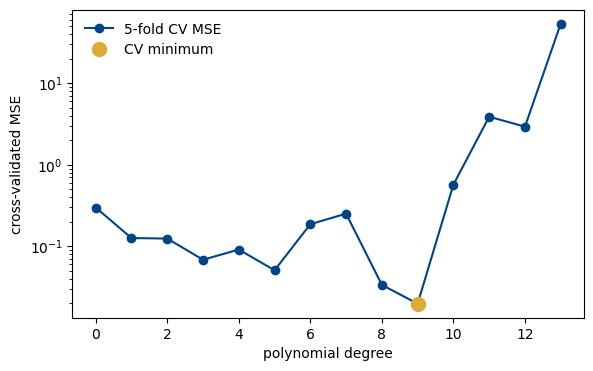

In [44]:
np.random.seed(2026)
n = 40
x1 = np.linspace(-3, 3, n).reshape(-1, 1)
y1 = np.exp(-x1**2) + 1.5 * np.exp(-(x1 - 2)**2) + np.random.normal(0, 0.1, x1.shape)

maxdegree = 14
kf = KFold(n_splits=5, shuffle=True, random_state=2026)
cv_mse = np.zeros(maxdegree)
for degree in range(maxdegree):
    pipe = make_pipeline(PolynomialFeatures(degree=degree),
                         LinearRegression(fit_intercept=False))
    scores = -cross_val_score(pipe, x1, y1.ravel(), cv=kf,
                              scoring="neg_mean_squared_error")
    cv_mse[degree] = scores.mean()

best_deg = np.argmin(cv_mse)
print(f"CV selects degree {best_deg} (CV-MSE {cv_mse[best_deg]:.4f})")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), cv_mse, "o-", color=BLUE, label="5-fold CV MSE")
ax.plot(best_deg, cv_mse[best_deg], "o", color=YELLOW, ms=10, label="CV minimum")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()

**Checkpoint:** cross-validation lands in the same broad degree window as the
bootstrap decomposition of Case 1 — two independent methods, one answer. That
agreement, not any single number, is what you should learn to look for.

---

### Step 5: the full recipe — standard errors, the one-standard-error rule, refit, and one look at the test set

Steps 1–4 chose $\lambda$ by the minimum of the CV curve. Section 3.14 of the
book adds what a complete, honest procedure needs:

* the **standard error** of the CV estimate, from the spread over the $k$
  folds, Eq. (3.93) — the CV curve is flat near its minimum, and the minimum
  is only determined to within this noise;
* the **one-standard-error rule**, Eq. (3.96): among all $\lambda$ whose CV
  error lies within one standard error of the best, take the *largest* — the
  most regularised model the data cannot distinguish from the best one;
* the **refit**: the fold models were temporary; the final model is a new fit
  at the selected $\lambda$ to *all* training data (the pipeline takes care
  that the scaler is refitted too);
* the **test set, once**: set aside at the start, never used to choose
  anything, and looked at exactly once at the end.

We own the generating process, so we can draw a test set of 1000 points; in a
real problem it is the part of the data you locked away before Step 1.

One convention to keep in mind (Section 3.14, "the factor $n$"):
`scikit-learn`'s `Ridge` minimises $\|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\theta}\|^2+\alpha\|\boldsymbol{\theta}\|^2$
without the $1/n$ of the book's Eq. (3.43), so its `alpha` is the book's
$n\lambda$; we keep calling the grid variable $\lambda$ as on Monday, and it
is `alpha`.

In [45]:
x_test = rng.standard_normal(1000)          # the test set: set aside, used once at the end
y_test = 3 * x_test**2 + rng.standard_normal(1000)

def cv_curve(make_model, alphas, x, y, cv):
    """Mean and standard error over folds of the CV-MSE, for every alpha."""
    mean, se = np.zeros(len(alphas)), np.zeros(len(alphas))
    for i, a in enumerate(alphas):
        scores = -cross_val_score(make_model(a), x[:, np.newaxis], y, cv=cv,
                                  scoring="neg_mean_squared_error")
        mean[i], se[i] = scores.mean(), scores.std(ddof=1) / np.sqrt(len(scores))
    return mean, se

def select(alphas, mean, se):
    """The minimum-CV alpha, and the largest alpha within one standard error of it."""
    i = np.argmin(mean)
    return alphas[i], alphas[mean <= mean[i] + se[i]].max()

ridge_model = lambda a: make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                                      Ridge(alpha=a))
mean_r, se_r = cv_curve(ridge_model, lambdas, x, y, kfold)
a_min, a_1se = select(lambdas, mean_r, se_r)

for name, a in (("min-CV", a_min), ("one-SE", a_1se)):
    j = np.searchsorted(lambdas, a)
    final = ridge_model(a).fit(x[:, np.newaxis], y)        # the refit on ALL training data
    test_mse = np.mean((final.predict(x_test[:, np.newaxis]) - y_test)**2)   # used once
    print(f"Ridge {name}: lambda {a:8.4g}  CV {mean_r[j]:.3f} +- {se_r[j]:.3f}  test {test_mse:.3f}")

Ridge min-CV: lambda    1.177  CV 1.457 +- 0.210  test 1.189
Ridge one-SE: lambda    2.057  CV 1.573 +- 0.215  test 1.187


**Reading the numbers:** the standard error of the CV estimate is about $0.2$,
so the minimum at $\lambda\approx1.2$ and the one-SE choice $\lambda\approx2.1$
are, as far as the folds can tell, the same model; the test errors of the two
refitted models agree to the third decimal ($1.19$, against the floor
$\sigma^2=1$; the degree-6 fit still carries some variance). Note also that
the CV estimate ($1.46$) is *above* the test error: fold models are fitted to
80 points instead of 100 and, for a polynomial in a Gaussian $x$, they must
extrapolate to whichever extreme $x$ landed in the held-out fold.
Cross-validation is, if anything, pessimistic.

### Step 6: Ridge and the Lasso side by side

Same data, same folds, same recipe, with the Lasso in the pipeline. Two things
to watch: where each method puts $\lambda_{\min}$ and $\lambda_{1\mathrm{SE}}$,
and — for the Lasso — *how many* of the six polynomial coefficients survive.
(`scikit-learn`'s `Lasso` minimises $\|\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\theta}\|^2/(2n)+\alpha\|\boldsymbol{\theta}\|_1$,
so its `alpha` is the book's $\lambda/2$ — a different convention from `Ridge`
in the same library, Section 3.10.)

Lasso min-CV: lambda   0.1353  CV 1.429 +- 0.212  test 1.030  non-zero: powers [2 4]
   coefficients: [ 0.    -0.     4.371  0.     0.033  0.     0.   ]
Lasso one-SE: lambda   0.3854  CV 1.606 +- 0.241  test 1.130  non-zero: powers [2]
   coefficients: [0.   0.   4.15 0.   0.   0.   0.  ]


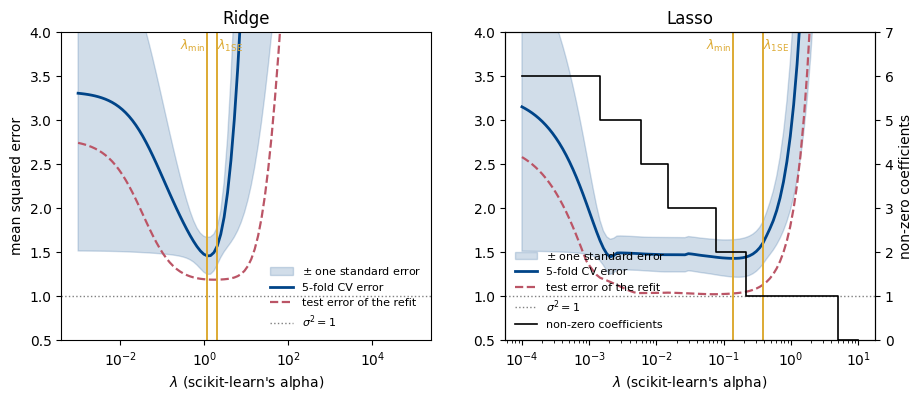

In [46]:
alphas_l = np.logspace(-4, 1, nlambdas)
lasso_model = lambda a: make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                                      Lasso(alpha=a, max_iter=100000))
mean_l, se_l = cv_curve(lasso_model, alphas_l, x, y, kfold)
b_min, b_1se = select(alphas_l, mean_l, se_l)

for name, a in (("min-CV", b_min), ("one-SE", b_1se)):
    j = np.searchsorted(alphas_l, a)
    final = lasso_model(a).fit(x[:, np.newaxis], y)
    coef = final[-1].coef_                    # order: 1, x, x^2, ..., x^6 (standardised columns)
    test_mse = np.mean((final.predict(x_test[:, np.newaxis]) - y_test)**2)
    print(f"Lasso {name}: lambda {a:8.4g}  CV {mean_l[j]:.3f} +- {se_l[j]:.3f}  test {test_mse:.3f}"
          f"  non-zero: powers {np.flatnonzero(coef)}")
    print("   coefficients:", np.round(coef, 3))

# the two recipes in one figure (this is week36_cv_ridge_lasso.pdf of the Tuesday slides)
grids = {"Ridge": lambdas, "Lasso": alphas_l}
models = {"Ridge": ridge_model, "Lasso": lasso_model}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for ax, name in zip(axes, ("Ridge", "Lasso")):
    alphas, make_model = grids[name], models[name]
    mean, se = cv_curve(make_model, alphas, x, y, kfold)
    a_lo, a_hi = select(alphas, mean, se)
    fits = [make_model(a).fit(x[:, np.newaxis], y) for a in alphas]     # refits on all training data
    test = np.array([np.mean((m.predict(x_test[:, np.newaxis]) - y_test)**2) for m in fits])
    ax.fill_between(alphas, mean - se, mean + se, color=BLUE, alpha=0.18,
                    label=r"$\pm$ one standard error")
    ax.semilogx(alphas, mean, color=BLUE, lw=2, label="5-fold CV error")
    ax.semilogx(alphas, test, "--", color=RED, lw=1.6, label="test error of the refit")
    ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"$\sigma^2=1$")
    for a, lab, ha in ((a_lo, r"$\lambda_{\min}$", "right"), (a_hi, r"$\lambda_{1\mathrm{SE}}$", "left")):
        ax.axvline(a, color=YELLOW, lw=1.4)
        ax.text(a, 3.75, lab + " ", ha=ha, va="bottom", fontsize=9, color=YELLOW)
    ax.set_ylim(0.5, 4.0); ax.set_xlabel(r"$\lambda$ (scikit-learn's alpha)"); ax.set_title(name)
    if name == "Lasso":
        nnz = [np.sum(m[-1].coef_ != 0) for m in fits]
        twin = ax.twinx()
        twin.semilogx(alphas, nnz, color="k", lw=1.2, drawstyle="steps-post",
                      label="non-zero coefficients")
        twin.set_ylim(0, 7); twin.set_ylabel("non-zero coefficients")
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = twin.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=8, loc="lower left")
    else:
        ax.set_ylabel("mean squared error"); ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()

**Checkpoint:** the Lasso *finds the model*. At $\lambda_{\min}$ it keeps two
of the six powers, $x^2$ (coefficient $4.4$ on the standardised column) and a
tiny $x^4$; at the one-SE choice it keeps $x^2$ alone — the data were generated
by $3x^2+\varepsilon$, and the one-standard-error rule has recovered exactly
that. Its test error, $1.03$ at $\lambda_{\min}$, sits right on the noise floor,
below Ridge's $1.19$: Ridge shrinks all six coefficients but sets none to zero,
so the five irrelevant powers keep contributing variance. This is the
book's Section 3.14 lesson in miniature — when the truth is sparse, the
$1$-norm penalty is the right prior (Section 3.11) — and it is why the two
methods reach the *same* error on the Franke function of Section 3.15, where
nothing is exactly zero.

In the figure, note how flat both CV curves are around their minima compared
with the width of the standard-error band: the second decimal of
$\lambda_{\min}$ is not a property of the data. Re-run Steps 5–6 with
`random_state=1` in `KFold` and watch $\lambda_{\min}$ move while the test
error of the refit barely changes.

### Step 7: why cross-validation, and not the bootstrap, chooses $\lambda$

Monday used the bootstrap to *measure* the bias-variance decomposition. Could it
also estimate the test error and pick $\lambda$? Section 3.14 goes through it;
here is the experiment. A bootstrap sample contains on average only
$1-(1-1/n)^n\to63.2\%$ of the distinct observations (Eq. (3.97)). Three
estimates follow: the **training (apparent) error**, optimistic; the
**leave-one-out bootstrap**, Eq. (3.98) — every point predicted only by models
that never saw it, but those models were fitted to $\sim63$ distinct points, so
it is pessimistic; and Efron's **.632 estimator**, Eq. (3.99),
$0.368\,\overline{\mathrm{err}}+0.632\,\mathrm{Err}^{(1)}$, which splits the
difference by a heuristic.

In [50]:
def bootstrap_errors(make_model, a, x, y, B=100, rng=None):
    """Training (apparent) error, leave-one-out bootstrap error, and the .632 estimate."""
    rng = np.random.default_rng() if rng is None else rng
    n = len(y)
    full = make_model(a).fit(x[:, np.newaxis], y)
    apparent = np.mean((full.predict(x[:, np.newaxis]) - y)**2)
    err_sum, err_count = np.zeros(n), np.zeros(n)
    for _ in range(B):
        idx = rng.integers(0, n, n)                          # draw n with replacement
        out = np.setdiff1d(np.arange(n), idx)                # the points left out
        m = make_model(a).fit(x[idx, np.newaxis], y[idx])
        err_sum[out] += (m.predict(x[out, np.newaxis]) - y[out])**2
        err_count[out] += 1
    seen = err_count > 0
    loo_boot = np.mean(err_sum[seen] / err_count[seen])
    return apparent, loo_boot, 0.368 * apparent + 0.632 * loo_boot

print(f"{'lambda':>8} {'train':>7} {'CV':>7} {'LOO-boot':>9} {'.632':>7} {'test':>7}")
for a in (1e-3, a_min, a_1se, 1e3):
    j = np.searchsorted(lambdas, a)
    apparent, loo_boot, e632 = bootstrap_errors(ridge_model, a, x, y, B=100,
                                                rng=np.random.default_rng(2026))
    final = ridge_model(a).fit(x[:, np.newaxis], y)
    test_mse = np.mean((final.predict(x_test[:, np.newaxis]) - y_test)**2)
    print(f"{a:8.3g} {apparent:7.3f} {mean_r[j]:7.3f} {loo_boot:9.3f} {e632:7.3f} {test_mse:7.3f}")

# where does each estimator put the minimum?  (a coarser grid, B = 100 fits per point)
coarse = lambdas[::4]
boot = np.array([bootstrap_errors(ridge_model, a, x, y, B=100, rng=np.random.default_rng(2026))
                 for a in coarse])
test = np.array([np.mean((ridge_model(a).fit(x[:, np.newaxis], y).predict(x_test[:, np.newaxis])
                          - y_test)**2) for a in coarse])
print(f"argmin lambda: CV {a_min:.3g}  LOO-bootstrap {coarse[np.argmin(boot[:, 1])]:.3g}"
      f"  .632 {coarse[np.argmin(boot[:, 2])]:.3g}  test {coarse[np.argmin(test)]:.3g}")

  lambda   train      CV  LOO-boot    .632    test
   0.001   1.310   3.305     6.914   4.851   2.742
    1.18   1.323   1.457     2.744   2.221   1.189
    2.06   1.336   1.573     2.866   2.303   1.187
   1e+03  13.414  13.247    11.615  12.277  13.686
argmin lambda: CV 1.18  LOO-bootstrap 0.811  .632 0.811  test 1.71


**Reading the table:** at the interesting penalties the leave-one-out
bootstrap overestimates the test error by more than a factor of two, and the
.632 correction still leaves it far too high — the fold models of $k$-fold CV
see 80 distinct points, the bootstrap models only about 63, and a degree-6
polynomial fitted to 63 points of a Gaussian $x$ extrapolates badly to the rest.
(At $\lambda=10^3$ every model predicts the mean, nothing is being fitted, and
all five columns agree.) All estimators nevertheless put their minimum in the
same flat valley, $\lambda\sim1$–$2$, because what matters for *selection* is
the location of the minimum, not the level of the curve. Section 3.14 draws the
conclusion: cross-validation is preferred for choosing $\lambda$ because its
bias is nearly constant in $\lambda$, because it costs $k$ fits per grid point
rather than a hundred, because its models see $(k-1)/k$ of the data rather
than $63\%$, and because it needs no correction constants. The bootstrap keeps
the job it did on Monday — estimating the *distribution* of a statistic —
and Step 8 shows the statistic cross-validation cannot assess.

### Step 8: which coefficients do you trust?  Bootstrap the Lasso's selection

At $\lambda_{\min}$ the Lasso kept $x^2$ and a small $x^4$. Is the $x^4$ real?
Refit the Lasso at the selected penalty to 200 bootstrap replicas of the
training set and count how often each power is selected — *stability
selection*, Section 3.14.

In [51]:
for name, a in (("min-CV", b_min), ("one-SE", b_1se)):
    rr, B, count = np.random.default_rng(2026), 200, np.zeros(7)
    for _ in range(B):
        idx = rr.integers(0, len(y), len(y))              # n = 100 training points
        count += lasso_model(a).fit(x[idx, np.newaxis], y[idx])[-1].coef_ != 0
    print(f"Lasso {name}: selection frequency of 1, x, ..., x^6 over {B} replicas:",
          np.round(count / B, 2))

Lasso min-CV: selection frequency of 1, x, ..., x^6 over 200 replicas: [0.   0.24 1.   0.06 0.58 0.   0.02]
Lasso one-SE: selection frequency of 1, x, ..., x^6 over 200 replicas: [0.   0.   1.   0.   0.34 0.   0.  ]


**Checkpoint:** $x^2$ is selected in every single replica; $x^4$ in about half
of them at $\lambda_{\min}$ and a third at $\lambda_{1\mathrm{SE}}$; the
odd powers rarely — $x$ in a quarter of the replicas at $\lambda_{\min}$ and
never at the one-SE choice. A coefficient that comes and goes with the resample
is one whose presence depends on which points happened to be drawn — that is
the operational meaning of "spurious" when the truth is unknown. Together:
cross-validation chose the penalty, the bootstrap told us which part of the
selected model to believe.

**If you want one more thing to try:** *nested* cross-validation. Reporting the
minimum of the CV curve as "the error of my model" is optimistic (the minimum
of a hundred noisy estimates is biased downwards). Wrap Steps 5–6 in an outer
5-fold loop, select $\lambda$ inside each outer training set, evaluate on the
outer held-out fold, and compare the outer average with $\mathrm{CV}(\lambda_{\min})$
from the inner loop and with the test error above.

---

## Extra (if time allows): the bootstrap and the central limit theorem

Monday's histogram figure, for completeness: the bootstrap distribution of the
sample mean of $10^4$ Gaussian numbers, against the CLT prediction
$\mathcal{N}(\mu, \sigma^2/n)$ of Eq. (2.24).

bootstrap std. error 0.15233   CLT sigma/sqrt(n) 0.15084


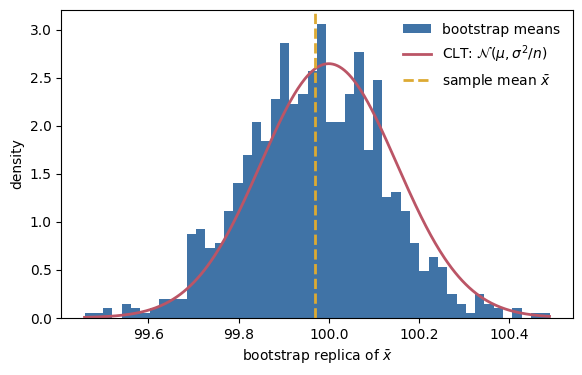

In [52]:
def bootstrap(data, statistic, k=1000, rng=None):
    """Bootstrap estimate of the distribution of a statistic."""
    rng = np.random.default_rng() if rng is None else rng
    n = len(data)
    replicas = np.empty(k)
    for i in range(k):
        sample = data[rng.integers(0, n, n)]   # draw n values with replacement
        replicas[i] = statistic(sample)
    return replicas


rng = np.random.default_rng(2026)
mu, sigma, ndata = 100.0, 15.0, 10000
data = rng.normal(mu, sigma, ndata)

t = bootstrap(data, np.mean, k=1000, rng=rng)
clt = np.std(data) / np.sqrt(ndata)
print(f"bootstrap std. error {np.std(t):.5f}   CLT sigma/sqrt(n) {clt:.5f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(t, bins=50, density=True, color=BLUE, alpha=0.75, label="bootstrap means")
grid = np.linspace(t.min(), t.max(), 400)
ax.plot(grid, norm.pdf(grid, mu, clt), color=RED, lw=2,
        label=r"CLT: $\mathcal{N}(\mu,\sigma^2/n)$")
ax.axvline(np.mean(data), color=YELLOW, lw=2, ls="--", label=r"sample mean $\bar{x}$")
ax.set_xlabel(r"bootstrap replica of $\bar{x}$")
ax.set_ylabel("density")
ax.legend(frameon=False)
plt.show()

Try replacing `np.mean` by `np.median`, or by a `lambda d: np.quantile(d, 0.9)`
— the bootstrap keeps working where no closed formula exists. That generality
is its whole point.

## Before you leave

- Make sure your group can state Eq. (2.52) and say which term each of today's
  experiments moved.
- Make sure you can run the complete selection recipe of Section 3.14 without
  looking: grid, $k$ folds with the scaler inside, CV mean and standard error,
  $\lambda_{\min}$ or $\lambda_{1\mathrm{SE}}$, refit on all training data, test
  set once — for Ridge and for the Lasso.
- Finish `exercisesweek36.ipynb` before **Friday September 4 at midnight**; the
  bootstrap and CV loops above are meant to be reused there (and in Project 1).
- Next Monday and week 38: the main focus shifts to *optimization* — gradient
  descent methods, from plain and steepest descent to stochastic gradient
  descent. We will also briefly mention the Bayesian reading of OLS, Ridge and
  Lasso (a Gaussian prior gives Ridge, a Laplace prior the Lasso).